# 統計的仮説検定

ある仮説が正しいかどうかを統計的に検証する手法。

というのがよくある説明だが、実際は、ある結果が偶然起こったものかそうでないかを検証する手法。有意でないという仮定の下でその結果が起こる確率（p値）を計算し、その確率が十分に小さい場合は有意であると結論づける。この時のしきい値を有意水準と呼び、これは事前に決めておく。大体5%、厳しめに見るときは1%がよく使われる。

In [1]:
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt

## 二項検定

二項分布を用いた検定。

### 例題1

> AさんとBさんでじゃんけんを100回行ったらAさんが65勝した。この偏りは有意かどうか。

有意水準は5%とする。

確率$\theta$のベルヌーイ試行を$n$回行った時の成功回数$k$は以下の二項分布に従う。

$$
\begin{align}

P(k) = \binom{n}{k} \theta^k (1-\theta)^{n-k}

\end{align}
$$

例題における、有意でないという仮定の下、つまり$n=100, \theta = 0.5$のとき、片方が65勝以上する確率を求める。これがp値となる。

$$
\begin{align}

p
&= 2 \cdot P(k \geq 65) \\
&= 2 \cdot \sum_{k=65}^{100} \binom{100}{k} 0.5^k (1-0.5)^{100-k}

\end{align}
$$

今回は偏りを見ているので、AさんBさんのいずれかが65勝以上する確率を求める。$\theta=0.5$の二項分布は左右対称なので、片方が65勝以上する確率を求めて、それを2倍する。この用に両方の確率を求める検定を両側検定と呼ぶ。反対に片方の確率だけを求める検定は片側検定と呼ぶ。

以下の図における赤い部分の面積を求めるという意味になる。

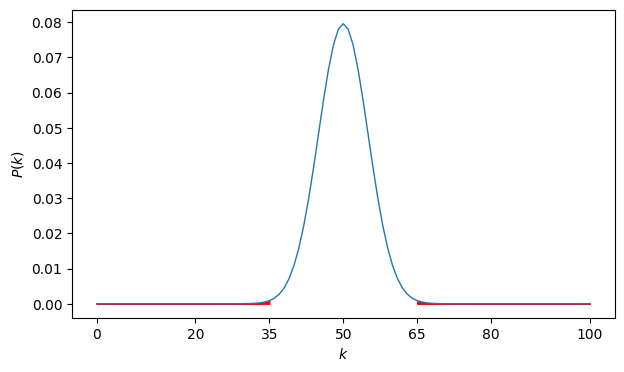

In [2]:
theta = 0.5
n = 100
k_ = np.arange(0, n+1)
p = stats.binom.pmf(k_, n, theta)
plt.figure(figsize=(7, 4))
plt.plot(k_, p, linewidth=1)
plt.fill_between(k_, p, where=(k_ >= 65), color="red")
plt.fill_between(k_, p, where=(k_ <= 35), color="red")
plt.xlabel("$k$")
plt.ylabel("$P(k)$")
plt.xticks([0, 20, 35, 50, 65, 80, 100]);

実際に計算するとこうなる。

In [3]:
p = 2 * (1 - stats.binom.cdf(64, 100, 0.5))
print(p)

0.0035176417229700885


0.3%ということで、5%を下回ったので有意であると結論づける。AさんがBさんの癖を見抜いているなど、何らかの理由があると考えられる。

### 例題2

> プロ野球の交流戦では、通算でパ・リーグが1369勝1217敗78分で勝ち越している。この結果から、パ・リーグはセ・リーグより強いと言えるかどうか。

In [4]:
n = 1369 + 1217
k = 1369
p = 2 * (1 - stats.binom.cdf(k-1, n, 0.5))
print(p)

0.0029769530584686787


引き分けは除外して考えた。p=0.2%ということで、偶然ではなく、有意にパ・リーグの方が強いと言える。

## z検定

正規分布を用いた検定（母分散既知）。

### 例題

> 例年のテストの平均点は60点である。今年の学生はどうやら優秀そうで、次のような点数だった。今年の学生は優秀であると言えるか。  
> なお、テストの点数は正規分布に従い、母分散は100とする。

In [5]:
x = np.array([65, 43, 56, 70, 62, 68, 83, 71, 80, 66, 72, 59, 77, 69, 73])
x_bar = np.mean(x)
n = len(x)
print("平均点:", x_bar)
print("サンプルサイズ:", n)

平均点: 67.6
サンプルサイズ: 15


平均$\mu$、分散$\sigma^2$の正規分布に従う母集団から、サイズ$n$の標本を抽出したときの標本平均$\bar{x}$は以下の正規分布に従う。

$$
\begin{align}

\bar{x} \sim \mathcal{N} \left( \mu, \frac{\sigma^2}{n} \right)

\end{align}
$$

このまま計算してもいいが、標準化してから標準正規分布を用いて計算するのが一般的。

$$
\begin{align}

z = \frac{\bar{x} - \mu}{\sigma / \sqrt{n}} \sim \mathcal{N}(0, 1)

\end{align}
$$

標準化得点によく用いられる記号が$z$なので、z検定と呼ばれる。

これでp値を求めてみる。

In [6]:
mu = 60
sigma = 10

z = (x_bar - mu) / (sigma / np.sqrt(n))
p = 2 * (1 - stats.norm.cdf(z))
print(p)

0.0032455806288154143


0.3%ということで、5%を下回ったので有意であると結論づける。今年の学生は優秀であると言える。

ちなみに、標準正規分布における両側5%の点は±約1.96であることは覚えている人が多い。これを覚えていると、zが±1.96を超えているかどうかで有意かどうかを判断できる。当然今回も超えている。

In [7]:
print(z)

2.943467343117635


## t検定（1標本）

正規分布を用いた検定（母分散未知）。

大抵の場合で母分散は未知であるため、よく使われるのはこっち。

### 例題

先ほどの例題で、母分散が未知である場合を考える。

> 例年のテストの平均点は60点である。今年の学生はどうやら優秀そうで、次のような点数だった。今年の学生は優秀であると言えるか。  
> なお、テストの点数は正規分布に従うと仮定してよく、母分散は未知である。

In [8]:
# このデータはさっきと同じ
x = np.array([65, 43, 56, 70, 62, 68, 83, 71, 80, 66, 72, 59, 77, 69, 73])
x_bar = np.mean(x)
n = len(x)
print("平均点:", x_bar)
print("サンプルサイズ:", n)

平均点: 67.6
サンプルサイズ: 15


母分散が未知なので、標本分散を用いて標準化する。

$$
\begin{align}

t = \frac{\bar{x} - \mu}{s / \sqrt{n}} \sim t(n-1)

\end{align}
$$

この$t$は自由度$n-1$のt分布に従うことが知られている。t分布は正規分布と似た形をしているが、母分散ではなく標本分散を用いることで分散の不確実性が加わり、やや裾が厚くなっている。自由度が大きくなると、t分布は正規分布に近づいていく。

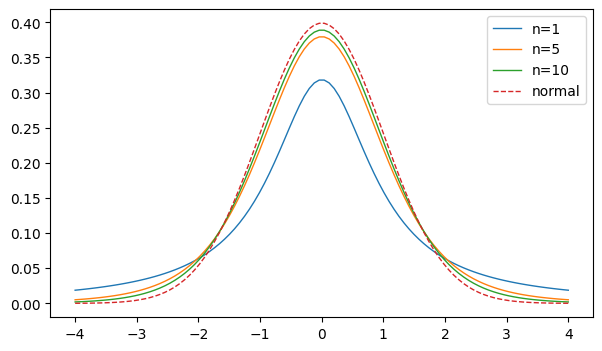

In [9]:
n_ = [1, 5, 10]
x_ = np.linspace(-4, 4, 100)

plt.figure(figsize=(7, 4))
for n in n_:
    p = stats.t.pdf(x_, df=n)
    plt.plot(x_, p, linewidth=1, label=f"n={n}")

p = stats.norm.pdf(x_)
plt.plot(x_, p, linewidth=1, label="normal", linestyle="dashed")
plt.legend();

ではこの$t$を用いてp値を求めてみる。

In [10]:
s = np.std(x, ddof=1) # 不偏標準偏差
t = (x_bar - mu) / (s / np.sqrt(n))
p = 2 * (1 - stats.t.cdf(t, df=n-1))
print(p)

0.03976995009444395


1%ということで、5%を下回ったので有意であると結論づける。今年の学生は優秀であると言える。

## 対応のある2標本t検定

サイズの同じ2つの標本があり、且つ各サンプルがペアとして考えられる（対応のある）とき、2つの標本の平均の差が有意かどうかを調べる。

### 例題

> あるクラスで、講義前のテストの点数と講義後のテストの点数を取った。講義によって成績が向上したかどうか。

In [11]:
x_pre = np.array([32, 43, 56, 35, 62, 82, 49, 40, 41, 66])
x_post = np.array([43, 45, 52, 38, 68, 80, 45, 55, 41, 67])
print("講義前の平均点:", np.mean(x_pre))
print("講義後の平均点:", np.mean(x_post))

講義前の平均点: 50.6
講義後の平均点: 53.4


各生徒の点数の差分が正規分布に従うと仮定する。（テストの点数が正規分布に従うと仮定できるなら、差分の正規性は自動的に満たされる。）

あとはこの差分について、平均0の正規分布に対する検定を1標本t検定で行うだけ。

In [12]:
diff = x_post - x_pre
diff_bar = np.mean(diff)
s_diff = np.std(diff, ddof=1)
mu = 0
t = (diff_bar - mu) / (s_diff / np.sqrt(n))
p = 1 - stats.t.cdf(t, df=n-1) # 講義によって点数が向上するかどうかを調べるので、片側検定
print(p)

0.0957015273495182


9%ということで、5%を上回ったので有意でないと結論づける。講義によって点数が向上したとは言えない。